In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/bank_cleaned.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group,balance_segment,campaign_group,subscription
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,51-60,Medium,Low,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,41-50,Low,Low,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,31-40,Low,Low,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,41-50,Medium,Low,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,31-40,Low,Low,0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 45211
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              45211 non-null  int64
 1   job              45211 non-null  str  
 2   marital          45211 non-null  str  
 3   education        45211 non-null  str  
 4   default          45211 non-null  str  
 5   balance          45211 non-null  int64
 6   housing          45211 non-null  str  
 7   loan             45211 non-null  str  
 8   contact          45211 non-null  str  
 9   day              45211 non-null  int64
 10  month            45211 non-null  str  
 11  duration         45211 non-null  int64
 12  campaign         45211 non-null  int64
 13  pdays            45211 non-null  int64
 14  previous         45211 non-null  int64
 15  poutcome         45211 non-null  str  
 16  y                45211 non-null  str  
 17  age_group        45199 non-null  str 

In [4]:
subscription_rate = (
    df['subscription'].mean()*100
)

print(f"Subscription Rate: {subscription_rate: .2f}%")

Subscription Rate:  11.70%


In [5]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

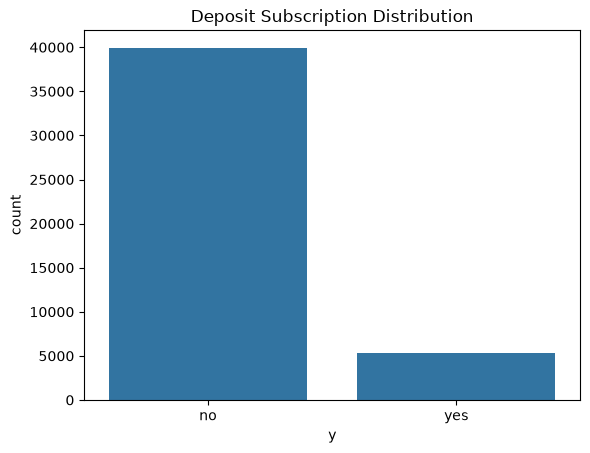

In [6]:
sns.countplot(data = df, x = 'y')
plt.title('Deposit Subscription Distribution')
plt.show()

### Deposit Subscription Distribution

The distribution of the target variable (`y`) shows a significant class imbalance in the dataset. Out of 45,211 customers, the majority did not subscribe to a term deposit, while only a small proportion accepted the offer.

#### Key Insights
- Approximately **88.3%** of customers did not subscribe (`No`).
- Approximately **11.7%** of customers subscribed (`Yes`).
- The low conversion rate reflects real-world banking marketing campaigns, where only a small fraction of customers respond positively.
- This imbalance highlights the importance of customer segmentation and targeted marketing strategies to improve campaign effectiveness.
- For analytical and dashboarding purposes, the original distribution is retained to accurately represent business reality.

#### Business Implication
The bank should focus on identifying characteristics of customers who are more likely to subscribe and optimize marketing efforts toward those high-potential segments, reducing acquisition costs and improving campaign ROI.

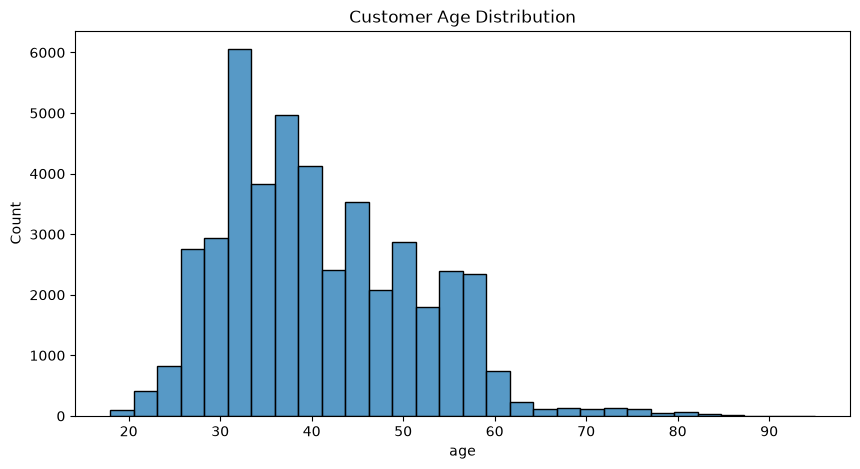

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x = 'age', bins = 30)

plt.title('Customer Age Distribution')

plt.show()

### Customer Age Distribution

The age distribution of banking customers is concentrated between **30 and 50 years**, with the highest customer density observed in the **early-to-mid 30s**. The distribution is moderately right-skewed, indicating that the customer base is primarily composed of working-age individuals, while senior customers represent a smaller segment.

#### Key Insights
- The majority of customers fall within the **30–50 age range**.
- Customer concentration peaks around **32–40 years of age**.
- The number of customers gradually declines after age 50.
- Very few customers are younger than 25 or older than 70.
- The customer base is dominated by economically active individuals, making them a valuable target for banking products and investment offerings.

#### Business Implications
- Marketing campaigns should primarily target customers aged **30–50**, as they represent the largest customer segment.
- Customers in this age group are likely to have stable income, active financial commitments, and higher potential for term deposit subscriptions.
- Specialized financial products and retirement planning services can be designed for older customer segments (60+).
- Younger customers may require different engagement strategies focused on savings, digital banking, and financial education.

In [9]:
age_analysis = (
    df.groupby('age_group')['subscription'].mean().sort_values(ascending=False)*100
)

age_analysis

age_group
60+      42.255892
18-30    16.215446
31-40    10.244813
51-60    10.053304
41-50     9.066643
Name: subscription, dtype: float64

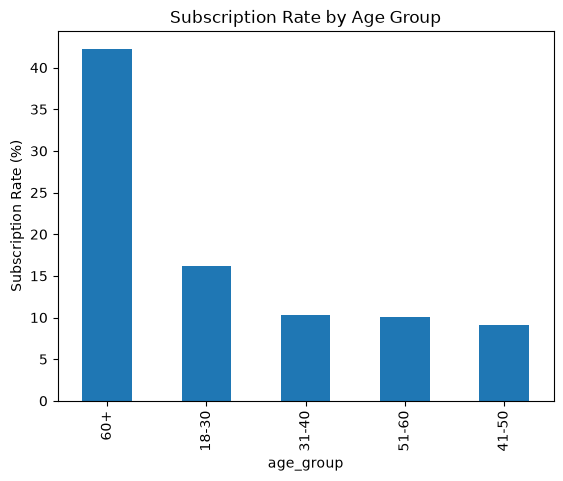

In [10]:
age_analysis.plot(kind = 'bar')

plt.ylabel('Subscription Rate (%)')
plt.title('Subscription Rate by Age Group')

plt.show()

### Subscription Rate by Age Group

This analysis compares the term deposit subscription rate across different customer age groups. The results reveal significant differences in customer responsiveness to banking marketing campaigns.

#### Key Insights
- Customers aged **60 and above** exhibit the highest subscription rate, exceeding **40%**, making them the most responsive customer segment.
- The **18–30 age group** shows the second-highest conversion rate at approximately **16%**.
- Customers between **31 and 60 years** demonstrate relatively similar subscription rates, ranging between **9% and 11%**.
- The **41–50 age group** records the lowest subscription rate among all segments.

#### Business Implications
- Senior customers (60+) represent a high-potential segment for term deposit products and should be prioritized in future marketing campaigns.
- Younger customers (18–30) also show strong engagement and may respond well to digital banking promotions, savings plans, and investment products.
- Middle-aged customers constitute a large portion of the customer base but exhibit lower conversion rates, indicating the need for more personalized marketing strategies.
- Targeted campaigns focusing on high-conversion age groups could significantly improve marketing efficiency and increase subscription rates.

#### Strategic Recommendation
The bank should adopt an age-based marketing strategy, allocating more resources toward senior customers and younger adults while designing customized offers to improve conversion among middle-aged customers.

In [12]:
job_conversion = (
    df.groupby('job')['subscription'].mean().sort_values(ascending=False)*100
)

job_conversion

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: subscription, dtype: float64

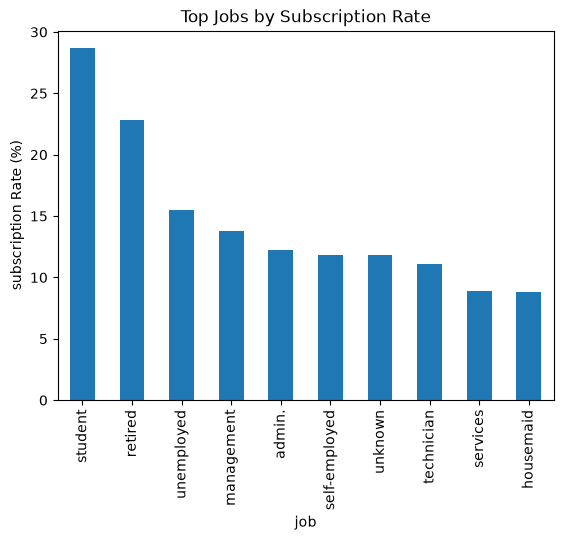

In [13]:
job_conversion.head(10).plot(kind = 'bar')

plt.title('Top Jobs by Subscription Rate')
plt.ylabel('subscription Rate (%)')

plt.show()

### Top Jobs by Subscription Rate

This analysis identifies the occupations with the highest term deposit subscription rates. The results indicate that customer profession plays a significant role in determining the likelihood of accepting banking investment products.

#### Key Insights
- **Students** exhibit the highest subscription rate at nearly **29%**, making them the most responsive customer segment.
- **Retired customers** show the second-highest conversion rate at approximately **23%**.
- **Unemployed customers** also demonstrate above-average subscription rates, exceeding **15%**.
- Professionals in **management**, **administration**, and **self-employed** categories show moderate subscription rates ranging between **11% and 14%**.
- **Housemaids**, **service workers**, and **technicians** have the lowest conversion rates among the top occupations displayed.

#### Business Implications
- Students and retirees represent high-potential customer groups and should be targeted with specialized savings and investment products.
- Retirement-focused financial plans and fixed-income investment products may be particularly attractive to retired customers.
- Young customers, especially students, present an opportunity for long-term relationship building and future cross-selling of banking services.
- Lower-performing occupational groups may require more personalized marketing campaigns or alternative product offerings to improve conversion rates.

#### Strategic Recommendation
The bank should implement occupation-based customer targeting by prioritizing students and retirees for deposit campaigns. This approach can improve marketing efficiency, increase conversion rates, and maximize return on marketing investments.

In [14]:
balance_segment_analysis = (
    df.groupby('balance_segment')['subscription'].mean()*100
)

balance_segment_analysis

balance_segment
High        15.506329
Low         10.896996
Medium      15.331750
Negative     6.895604
Name: subscription, dtype: float64

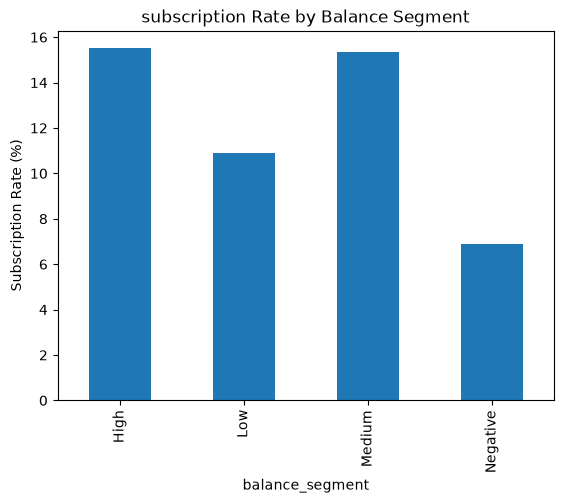

In [15]:
balance_segment_analysis.plot(kind='bar')

plt.title('subscription Rate by Balance Segment')
plt.ylabel('Subscription Rate (%)')

plt.show()

### Subscription Rate by Balance Segment

This analysis examines how customer account balance influences the likelihood of subscribing to a term deposit. The results reveal a clear relationship between a customer's financial position and campaign conversion rates.

#### Key Insights
- Customers with **High** and **Medium** account balances exhibit the highest subscription rates, both around **15%**.
- Customers with **Low** balances show a moderate subscription rate of approximately **11%**.
- Customers with **Negative** balances have the lowest conversion rate, below **7%**.
- The subscription rate increases as customer financial strength improves, indicating a positive relationship between account balance and product adoption.

#### Business Implications
- Customers with higher balances are more financially stable and have greater capacity to invest in banking products such as term deposits.
- Negative-balance customers are significantly less likely to subscribe, possibly due to financial constraints or lower savings capacity.
- High-value customers represent a key segment for deposit acquisition campaigns and should receive priority targeting.
- Financial wellness programs or savings incentives may be necessary to improve engagement among customers with low or negative balances.

#### Strategic Recommendation
The bank should prioritize medium- and high-balance customers when promoting term deposit products, as these segments generate the highest conversion rates. Personalized investment offers and premium banking services can further increase deposit subscriptions among financially strong customers.

In [16]:
housing_analysis = (
    df.groupby('housing')['subscription'].mean()*100
)

housing_analysis

housing
no     16.702355
yes     7.699960
Name: subscription, dtype: float64

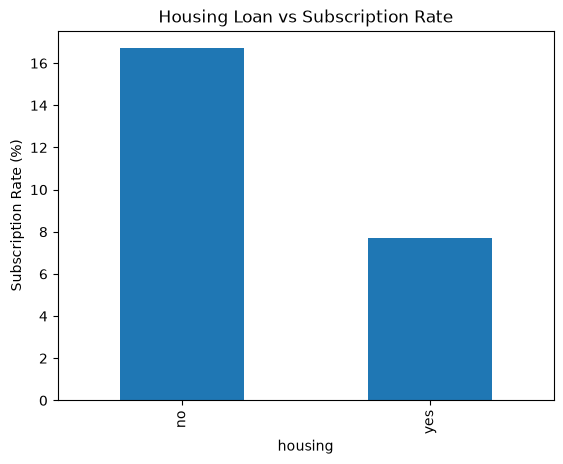

In [17]:
housing_analysis.plot(kind='bar')

plt.title('Housing Loan vs Subscription Rate')
plt.ylabel('Subscription Rate (%)')

plt.show()

### Housing Loan vs Subscription Rate

This analysis evaluates the impact of housing loan ownership on a customer's likelihood of subscribing to a term deposit. The results show a substantial difference in conversion behavior between customers with and without housing loans.

#### Key Insights
- Customers **without a housing loan** have a subscription rate of approximately **16.8%**.
- Customers **with a housing loan** have a significantly lower subscription rate of approximately **7.7%**.
- Customers without housing loans are more than **twice as likely** to subscribe to a term deposit compared to those currently servicing a housing loan.
- Housing loan obligations appear to reduce customers' willingness or ability to commit funds to investment products.

#### Business Implications
- Customers without housing loans represent a highly attractive target segment for term deposit campaigns.
- Existing housing loan commitments may limit disposable income available for savings and investment products.
- Marketing campaigns targeting customers with housing loans may require alternative product offerings such as flexible savings plans or bundled financial products.
- Customer debt obligations should be considered when designing investment-focused marketing strategies.

#### Strategic Recommendation
The bank should prioritize customers without housing loans when promoting term deposits, as this segment demonstrates significantly higher conversion rates. For customers with housing loans, personalized offers and financial planning solutions may help improve engagement and increase subscription likelihood.

#### Business Conclusion
Housing loan status is a strong indicator of customer investment behavior. Customers with fewer financial obligations exhibit a much higher propensity to invest in term deposits, making housing loan ownership a valuable feature for customer segmentation and campaign targeting.

In [18]:
loan_analysis = (
    df.groupby('loan')['subscription'].mean()*100
)

loan_analysis

loan
no     12.655727
yes     6.681391
Name: subscription, dtype: float64

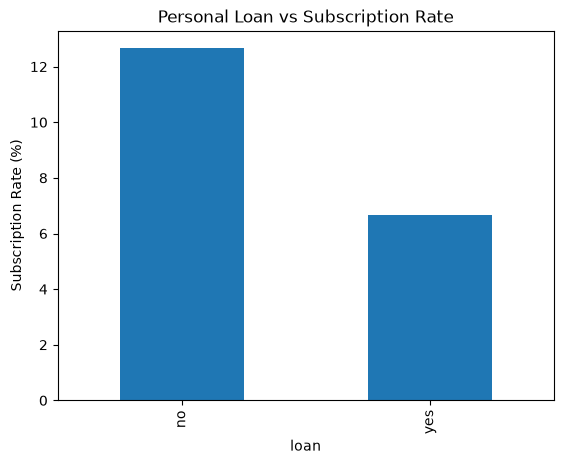

In [19]:
loan_analysis.plot(kind = 'bar')

plt.title('Personal Loan vs Subscription Rate')
plt.ylabel('Subscription Rate (%)')

plt.show()

### Personal Loan vs Subscription Rate

This analysis examines the relationship between personal loan ownership and term deposit subscription behavior. The results indicate that customers without personal loans are considerably more likely to subscribe to a term deposit than customers with existing loan obligations.

#### Key Insights
- Customers **without a personal loan** have a subscription rate of approximately **12.7%**.
- Customers **with a personal loan** have a subscription rate of approximately **6.7%**.
- Customers without personal loans are nearly **twice as likely** to subscribe compared to customers who currently have personal loan commitments.
- Personal loan obligations appear to reduce customers' available funds for long-term savings and investment products.

#### Business Implications
- Existing debt commitments negatively impact customers' willingness to invest in term deposits.
- Customers without personal loans represent a higher-value segment for deposit acquisition campaigns.
- Customers with active loans may prioritize debt repayment over savings and investment products.
- Alternative financial products such as flexible savings plans or debt management solutions may be more suitable for loan-holding customers.

#### Strategic Recommendation
The bank should prioritize customers without personal loans when promoting term deposits, as they demonstrate significantly higher conversion rates. Personal loan status should be incorporated into customer segmentation models to improve campaign targeting and marketing efficiency.

#### Business Conclusion
Personal loan ownership is a strong predictor of subscription behavior. Customers with fewer financial liabilities are more likely to invest in term deposits, making loan status an important factor in customer profiling and campaign optimization.

In [23]:
contact_analysis = (
    df.groupby('contact')['subscription']
    .mean()
    *100
 
)

contact_analysis

contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: subscription, dtype: float64

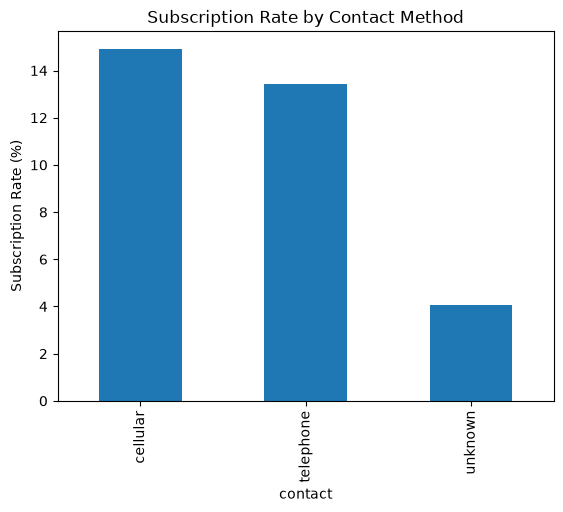

In [24]:
contact_analysis.plot(kind='bar')

plt.title('Subscription Rate by Contact Method')
plt.ylabel('Subscription Rate (%)')

plt.show()

### Subscription Rate by Contact Method

This analysis evaluates the effectiveness of different communication channels used during the bank's marketing campaigns. The results reveal substantial differences in customer response rates depending on the contact method employed.

#### Key Insights
- **Cellular contact** achieves the highest subscription rate at approximately **15%**, making it the most effective communication channel.
- **Telephone contact** performs slightly lower, with a subscription rate of around **13.5%**.
- Customers with an **unknown contact method** exhibit the lowest conversion rate at approximately **4%**.
- Both cellular and telephone channels significantly outperform the unknown category, indicating the importance of maintaining accurate customer contact information.

#### Business Implications
- Mobile-based outreach campaigns are more effective in engaging customers and generating term deposit subscriptions.
- Customers contacted through cellular channels are more accessible and responsive to marketing efforts.
- Poor or missing contact information negatively impacts campaign performance and conversion rates.
- Maintaining accurate customer communication records can directly improve marketing effectiveness and customer engagement.

#### Strategic Recommendation
The bank should prioritize cellular communication channels for future marketing campaigns and invest in improving customer contact data quality. Additionally, resources allocated to customers with unknown contact information should focus on data enrichment and customer record updates before campaign execution.

#### Business Conclusion
Contact method is a critical factor influencing campaign success. Customers reached through cellular devices demonstrate the highest likelihood of subscribing to term deposits, highlighting the importance of digital and mobile-first customer engagement strategies.

In [25]:
numeric_cols = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'subscription'
]

corr = (
    df[numeric_cols].corr()
)

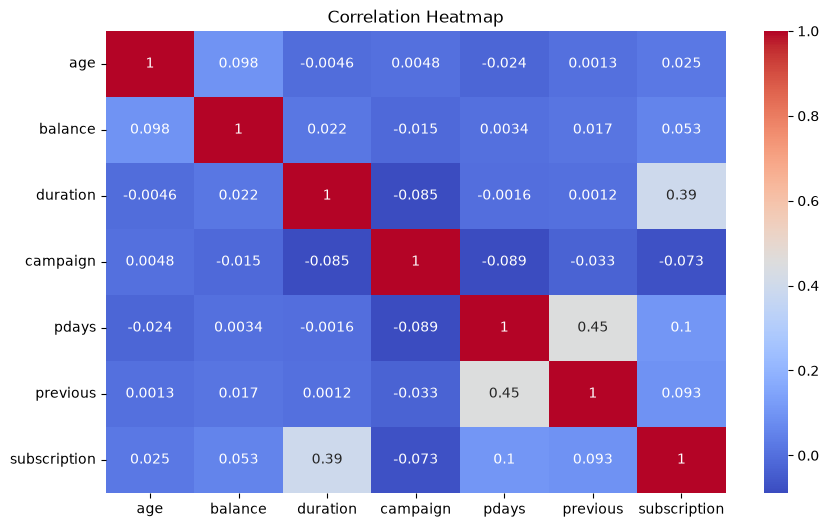

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### Correlation Heatmap Analysis

The correlation heatmap illustrates the relationships between key numerical variables in the banking dataset and their association with term deposit subscription behavior. Most variables exhibit weak correlations, indicating that customer subscription decisions are influenced by multiple factors rather than a single dominant variable.

#### Key Insights

- **Call Duration** shows the strongest positive correlation with subscription (`0.39`).
  - Customers who engage in longer conversations are significantly more likely to subscribe.
  - This suggests that customer engagement during marketing calls plays a crucial role in campaign success.

- **Previous Campaign Contacts (`previous`)** and **Days Since Last Contact (`pdays`)** exhibit a moderate positive correlation (`0.45`).
  - Customers who have been contacted previously are more likely to have recent campaign interaction history.

- **Previous Contacts** show a small positive relationship with subscription (`0.093`).
  - Existing customer relationships slightly improve conversion likelihood.

- **Campaign Contacts (`campaign`)** have a slight negative correlation with subscription (`-0.073`).
  - Excessive contact attempts may reduce customer responsiveness and campaign effectiveness.

- **Account Balance** shows a weak positive correlation (`0.053`) with subscription.
  - Financial strength contributes to conversion but is not a primary driver.

- **Age** has a very weak positive relationship (`0.025`) with subscription.
  - Age alone is not a strong predictor of customer behavior.

#### Business Implications

- Customer engagement during calls is one of the strongest indicators of successful conversion.
- Repeatedly contacting customers may lead to diminishing returns and lower campaign effectiveness.
- Existing customer relationships and prior interactions can improve marketing outcomes.
- Marketing strategies should focus on customer quality and engagement rather than increasing contact frequency.

#### Strategic Recommendation

The bank should prioritize high-quality customer interactions over aggressive outreach campaigns. Improving call effectiveness, targeting customers with prior engagement history, and optimizing contact frequency can significantly enhance conversion rates and marketing ROI.

#### Important Note

While call duration shows the strongest correlation with subscription, it should be interpreted carefully. In practice, longer conversations often occur because customers are already interested in the product rather than duration directly causing the subscription. Therefore, duration should be viewed as an indicator of customer engagement rather than a standalone driver of conversion.

In [28]:
job_conversion.to_csv("../data/job_conversion.csv")

balance_segment_analysis.to_csv("../data/balance_analysis.csv")

contact_analysis.to_csv("../data/contact_analysis.csv")

Summary of EDA

## Key Business Insights

### 1. Overall Campaign Performance

The bank achieved an overall term deposit subscription rate of **11.69%**, indicating that approximately 1 in every 9 customers accepted the offer.

**Business Insight:**
The relatively low conversion rate highlights the importance of customer segmentation and targeted marketing campaigns to improve marketing efficiency and reduce acquisition costs.

---

### 2. Age-Based Customer Analysis

Subscription rates vary significantly across age groups.

| Age Group | Subscription Rate |
|------------|------------------|
| 60+ | 42.26% |
| 18-30 | 16.22% |
| 31-40 | 10.24% |
| 51-60 | 10.05% |
| 41-50 | 9.07% |

**Key Findings:**
- Customers aged **60+** demonstrate the highest conversion rate, exceeding 42%.
- Younger customers aged **18-30** also show strong engagement.
- Middle-aged customers exhibit comparatively lower conversion rates.

**Business Recommendation:**
Prioritize senior customers and young adults in future deposit campaigns to maximize marketing ROI.

---

### 3. Occupation-Based Analysis

Certain occupations are significantly more likely to subscribe.

| Occupation | Subscription Rate |
|------------|------------------|
| Student | 28.68% |
| Retired | 22.79% |
| Unemployed | 15.50% |
| Management | 13.76% |
| Admin | 12.20% |

**Key Findings:**
- Students are the most responsive customer segment.
- Retired customers exhibit strong interest in deposit products.
- Professional occupations show moderate conversion rates.

**Business Recommendation:**
Develop occupation-specific marketing strategies and financial products targeting students and retirees.

---

### 4. Financial Strength Analysis

Customer balance has a clear impact on subscription behavior.

| Balance Segment | Subscription Rate |
|-----------------|------------------|
| High | 15.51% |
| Medium | 15.33% |
| Low | 10.90% |
| Negative | 6.90% |

**Key Findings:**
- Customers with medium and high balances convert at more than twice the rate of customers with negative balances.
- Financial stability strongly influences investment decisions.

**Business Recommendation:**
Prioritize medium- and high-balance customers when promoting term deposit products.

---

### 5. Loan Impact Analysis

Both housing loans and personal loans negatively impact subscription behavior.

**Key Findings:**
- Customers without housing loans convert more than twice as often as those with housing loans.
- Customers without personal loans demonstrate significantly higher subscription rates.

**Business Recommendation:**
Incorporate loan status into customer targeting models and focus campaigns on customers with lower debt obligations.

---

### 6. Campaign Communication Analysis

Communication channel significantly affects campaign success.

**Key Findings:**
- Cellular contact achieves the highest conversion rate.
- Telephone contact performs moderately well.
- Customers with unknown contact information have the lowest conversion rates.

**Business Recommendation:**
Invest in mobile-first marketing campaigns and improve customer contact data quality.

---

### Overall Conclusion

The analysis indicates that customer age, occupation, account balance, debt obligations, and communication channels are key drivers of term deposit subscription behavior. Senior customers, students, retirees, and financially stable customers represent the most valuable target segments for future marketing campaigns.